# Real-Time Face Mask Compliance Detection

In [2]:
# import libraries
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from glob import glob
import random

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0, MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

print("Libraries installed and imported successfully.")

Libraries installed and imported successfully.


In [ ]:
# Check TensorFlow and Keras versions

import tensorflow as tf
import keras

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)
print("tf.keras:", tf.keras.__version__)

TensorFlow: 2.20.0
Keras: 3.10.0
tf.keras: 3.10.0


## 1.0 Data Loading

### 1.1 Define Paths

In [ ]:
# Change to own dataset path before running the code cells
DATASET_PATH = r"C:\Users\HP\10_JupyterLab_DataSc\notebooks\Visual Information Processing\VIP_Project_Group_10\Real-Time-Face-Mask-Detection\Dataset"

class_dirs = ["with_mask", "without_mask", "mask_weared_incorrect"]
print("DATASET_PATH exists:", os.path.exists(DATASET_PATH))
for d in class_dirs:
    p = os.path.join(DATASET_PATH, d)
    print(d, "exists:", os.path.exists(p), "num_images:", len(glob(os.path.join(p, "*.*"))))

DATASET_PATH exists: True
with_mask exists: True num_images: 2994
without_mask exists: True num_images: 2994
mask_weared_incorrect exists: True num_images: 2994


## 2.0 Data Preprocessing

### 2.1 Visual Sanity Check

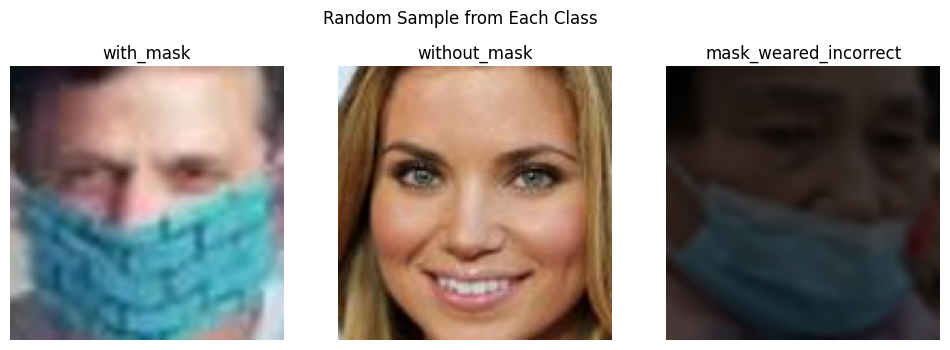

In [5]:
# picks one random image from each of the three folders and displays it on the screen. 
# to ensure the data isn't corrupted and to visually confirm what "Incorrect Mask" looks like
# helps us verify that the dataset is actually cropped faces, not full-body images

plt.figure(figsize=(12, 4))
for idx, class_name in enumerate(class_dirs):
    img_dir = os.path.join(DATASET_PATH, class_name)
    img_files = glob(os.path.join(img_dir, "*.*"))
    if not img_files:
        print(f"No images found in {class_name}")
        continue
    img_path = random.choice(img_files)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(1, 3, idx + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')
plt.suptitle("Random Sample from Each Class")
plt.show()

### 2.2 Configuration and Data Augmentation

In [6]:
# This sets up the ImageDataGenerator. This is a tool that:
# 1. Rescales: Converts pixel colors from 0-255 to 0-1 (Neural networks like small numbers).
# 2. Splits: Automatically reserves 20% of the data for testing (Validation).
# 3. Augments: Defines rules to randomly rotate, zoom, or shift images during training. Why it is needed: Augmentation is critical for your project because "Incorrect Mask" detection is subtle. By randomly tilting images, we teach the model to recognize a nose slipping out even if the person's head isn't perfectly straight.
# Set up ImageDataGenerator for training and validation

train_datagen = ImageDataGenerator(
    rotation_range=15,             # 3. Randomly rotate images by up to 15 degrees
    width_shift_range=0.1,         # 3. Randomly shift images horizontally
    height_shift_range=0.1,        # 3. Randomly shift images vertically
    zoom_range=0.1,                # 3. Randomly zoom images
    horizontal_flip=True,          # 3. Randomly flip images horizontally
    validation_split=0.2           # 2. Reserve 20% of data for validation
)
print("ImageDataGenerator configured for augmentation and validation split.")

ImageDataGenerator configured for augmentation and validation split.


### 2.3 Create Train and Validation Generators

In [ ]:
# This actually connects the datagen (the rules) to your DATASET_PATH 
# (the files). It creates two "streams" of data: train_gen and val_gen. 
# These two variables (train_gen and val_gen) are what you will feed 
# directly into the model training command (model.fit) in Section 3.0.
# Create training and validation data generators
train_gen = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)
print(f"[INFO] Training generator: Found {train_gen.samples} images belonging to {train_gen.num_classes} classes. These will be used for training.")

# Validation generator
val_gen = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False 
)
print(f"[INFO] Validation generator: Found {val_gen.samples} images belonging to {val_gen.num_classes} classes. These will be used for validation.")

# Print class indices for reference (used later in evaluation and application)
print(f"[INFO] Class indices mapping: {train_gen.class_indices}")

Found 7188 images belonging to 3 classes.
[INFO] Training generator: Found 7188 images belonging to 3 classes. These will be used for training.
Found 1794 images belonging to 3 classes.
[INFO] Validation generator: Found 1794 images belonging to 3 classes. These will be used for validation.
[INFO] Class indices mapping: {'mask_weared_incorrect': 0, 'with_mask': 1, 'without_mask': 2}


## 3.0 Model A: EfficientNet-B0

### 3.1 Build Architecture

In [ ]:
# Load the EfficientNetB0 model pre-trained on ImageNet.
# include_top=False removes the final classification layer (which was made for 1000 objects like cats/dogs).
# Then add "Custom Head" to classify the 3 specific mask categories.

# 1. Load the base model with pre-trained ImageNet weights
base_model_eff = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# 2. Freeze the base model
# This ensures the pre-learned features (like edges and shapes)are not destroyed during the initial training.
base_model_eff.trainable = False 

# 3. Add Custom Head
x = base_model_eff.output
x = GlobalAveragePooling2D()(x)                # summarize the features
x = Dense(256, activation='relu')(x)           # specific layer to learn mask patterns
x = Dropout(0.5)(x)                            # dropout prevents overfitting
predictions = Dense(3, activation='softmax')(x) # final layer: 3 Neurons for 3 Classes (Softmax for probability)

# 4. Construct the final model
model_eff = Model(inputs=base_model_eff.input, outputs=predictions)

# 5. Compile the model
# use Adam optimizer and Categorical Crossentropy as we have more than 2 classes.
model_eff.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

print("EfficientNet-B0 model built and compiled successfully.")
model_eff.summary()

EfficientNet-B0 model built and compiled successfully.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,378,278 (16.70 MB)

 Trainable params: 328,707 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

### 3.2 Train Model

In [ ]:
# This fits the model to the training data. 
# Use 15 epochs for the training. The 'val_gen' is used to check performance after every epoch.

print("Starting training for EfficientNet-B0...")

history_eff = model_eff.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    steps_per_epoch=len(train_gen),
    validation_steps=len(val_gen)
)

print("Training completed.")

# Save training history to JSON file for later analysis
import json
history_path = os.path.join(os.getcwd(), 'training_history.json')
try:
    existing = {}
    if os.path.exists(history_path):
        with open(history_path, 'r') as f:
            existing = json.load(f)
    existing['EfficientNetB0'] = {
        'accuracy': history_eff.history.get('accuracy', []),
        'val_accuracy': history_eff.history.get('val_accuracy', []),
        'loss': history_eff.history.get('loss', []),
        'val_loss': history_eff.history.get('val_loss', [])
    }
    with open(history_path, 'w') as f:
        json.dump(existing, f)
    print(f"[INFO] Saved EfficientNetB0 training history to {history_path}")
except Exception as e:
    print(f"[WARNING] Failed to save training history: {e}")

Starting training for EfficientNet-B0...


e:\HP_E\00_Apps_Software\Anaconda3\envs\CDS6334\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 259s 1s/step - accuracy: 0.9031 - loss: 0.2442 - val_accuracy: 0.9705 - val_loss: 0.0843
Epoch 2/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 221s 984ms/step - accuracy: 0.9736 - loss: 0.0703 - val_accuracy: 0.9682 - val_loss: 0.0949
Epoch 3/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 247s 1s/step - accuracy: 0.9808 - loss: 0.0575 - val_accuracy: 0.9783 - val_loss: 0.0677
Epoch 4/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 267s 1s/step - accuracy: 0.9840 - loss: 0.0450 - val_accuracy: 0.9844 - val_loss: 0.0550
Epoch 5/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 239s 1s/step - accuracy: 0.9859 - loss: 0.0376 - val_accuracy: 0.9838 - val_loss: 0.0467
Epoch 6/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 270s 1s/step - accuracy: 0.9848 - loss: 0.0436 - val_accuracy: 0.9872 - val_loss: 0.0419
Epoch 7/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 258s 1s/step - accuracy: 0.9899 - loss: 0.0298 - val_accuracy: 0.9889 - val_loss: 0.0381
Epoch 8/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 299s 1s/step - accuracy: 0.9879 - loss: 0.0349 - val_a

In [12]:
# Save the trained model in .h5 format for later use 
model_eff.save('mask_detector_efficientnet.h5')
print("Model saved as 'mask_detector_efficientnet.h5'")

Model saved as 'mask_detector_efficientnet.h5'


## 4.0 Model B: MobileNetV2

### 4.1 Build Architecture

In [ ]:
# Load the base model with pre-trained ImageNet weights
base_model_mob = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model to ensure the pre-learned features are not destroyed during the initial training
base_model_mob.trainable = False 

# Add Custom Head
x = base_model_mob.output
x = GlobalAveragePooling2D()(x)             
x = Dense(256, activation='relu')(x)   
x = Dropout(0.5)(x)    # prevents overfitting
predictions = Dense(3, activation='softmax')(x) 

# Construct the final model
model_mob = Model(inputs=base_model_mob.input, outputs=predictions)

# Compile the model
# use Adam optimizer and Categorical Crossentropy
model_mob.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

print("MobileNetV2 model built and compiled successfully.")
model_mob.summary()

MobileNetV2 model built and compiled successfully.


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,586,691 (9.87 MB)

 Trainable params: 328,707 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

### 4.2 Train

In [ ]:
# Use 15 epochs for the training
print("Starting training for MobileNetV2...")

history_mob = model_mob.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    steps_per_epoch=len(train_gen),
    validation_steps=len(val_gen)
)

print("Training completed.")

# Save training history to JSON file for later analysis
import json
history_path = os.path.join(os.getcwd(), 'training_history.json')
try:
    existing = {}
    if os.path.exists(history_path):
        with open(history_path, 'r') as f:
            existing = json.load(f)
    existing['MobileNetV2'] = {
        'accuracy': history_mob.history.get('accuracy', []),
        'val_accuracy': history_mob.history.get('val_accuracy', []),
        'loss': history_mob.history.get('loss', []),
        'val_loss': history_mob.history.get('val_loss', [])
    }
    with open(history_path, 'w') as f:
        json.dump(existing, f)
    print(f"[INFO] Saved MobileNetV2 training history to {history_path}")
except Exception as e:
    print(f"[WARNING] Failed to save training history: {e}")


Starting training for MobileNetV2...
Epoch 1/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 282s 1s/step - accuracy: 0.6936 - loss: 0.7308 - val_accuracy: 0.8205 - val_loss: 0.4496
Epoch 2/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 247s 1s/step - accuracy: 0.8289 - loss: 0.4278 - val_accuracy: 0.8562 - val_loss: 0.3480
Epoch 3/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 228s 1s/step - accuracy: 0.8655 - loss: 0.3403 - val_accuracy: 0.8757 - val_loss: 0.3134
Epoch 4/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 240s 1s/step - accuracy: 0.8840 - loss: 0.3034 - val_accuracy: 0.8863 - val_loss: 0.2700
Epoch 5/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 226s 1s/step - accuracy: 0.8882 - loss: 0.2933 - val_accuracy: 0.8952 - val_loss: 0.2701
Epoch 6/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 192s 855ms/step - accuracy: 0.8849 - loss: 0.2856 - val_accuracy: 0.9041 - val_loss: 0.2451
Epoch 7/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 191s 849ms/step - accuracy: 0.8728 - loss: 0.3057 - val_accuracy: 0.8986 - val_loss: 0.2686
Epoch 8/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 213s 946ms/ste

In [14]:
# Save the trained model for later use
model_mob.save('mask_detector_mobilenetv2.h5')
print("Model saved as 'mask_detector_mobilenetv2.h5'")

Model saved as 'mask_detector_mobilenetv2.h5'


## 5.0 Comparative Evaluation

Rebuild the architecture for EfficientNetB0 and MobileNetV2 models and convert them into .keras format for evaluation

In [ ]:
# EfficientNet rebuild model architecture and load weights

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

# Rebuild architecture EXACTLY as training
base_model = EfficientNetB0(
    weights=None,              # must be None to match weights file
    include_top=False,
    input_shape=(224, 224, 3)
)

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(3, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

print("Model architecture rebuilt")

model.load_weights("mask_detector_efficientnet.h5")
print("Weights loaded successfully")

model.save("mask_detector_efficientnet.keras")
print("Saved clean model: mask_detector_efficientnet.keras")

test_model = tf.keras.models.load_model("mask_detector_efficientnet.keras")
print("Model reload successful")



Model architecture rebuilt
Weights loaded successfully
Saved clean model: mask_detector_efficientnet.keras
Model reload successful


In [ ]:
# MobileNetV2 rebuild model architecture and load weights

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    weights=None,              # must be None to match weights file
    include_top=False,
    input_shape=(224, 224, 3)
)

x = base_model.output
x = GlobalAveragePooling2D()(x)

# Custom dense layer (256 units)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

outputs = Dense(3, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

print("MobileNetV2 architecture rebuilt (256-dense)")

model.load_weights("mask_detector_mobilenetv2.h5")
print("Weights loaded successfully")

model.save("mask_detector_mobilenetv2.keras")
print("Saved: mask_detector_mobilenetv2.keras")

tf.keras.models.load_model("mask_detector_mobilenetv2.keras")
print("Reload successful — model is clean")

MobileNetV2 architecture rebuilt (256-dense)
Weights loaded successfully
Saved: mask_detector_mobilenetv2.keras
Reload successful — model is clean


### 5.1 Training History Plots

Draws line graphs comparing how both models learned to check how fast models learn and whether there's overfitting or not.

[INFO] Loaded training history from c:\Users\HP\10_JupyterLab_DataSc\notebooks\Visual Information Processing\VIP_Project_Group_10\Real-Time-Face-Mask-Detection\training_history.json


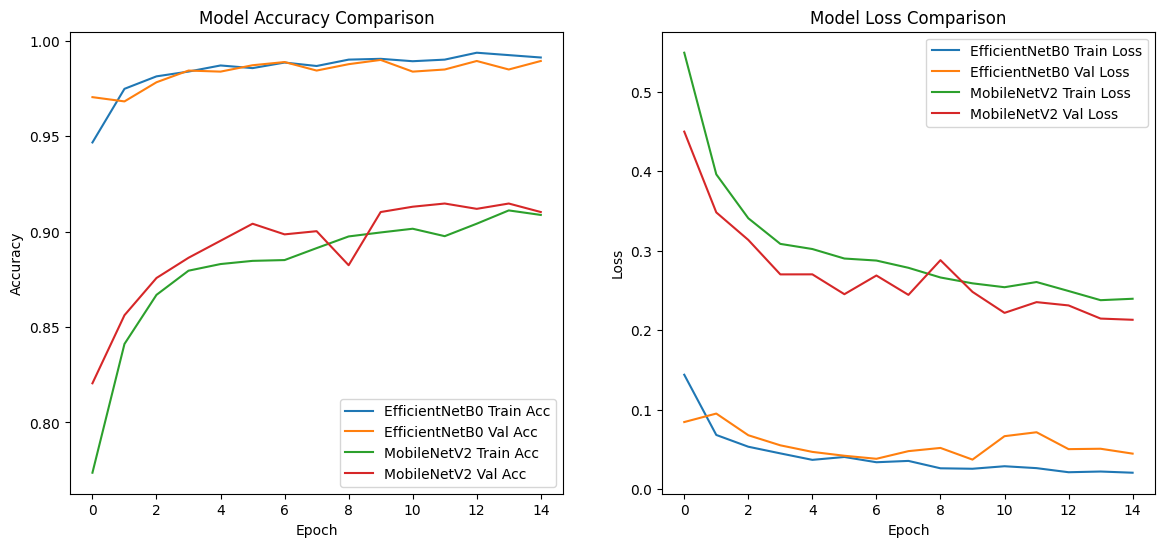

57/57 ━━━━━━━━━━━━━━━━━━━━ 57s 964ms/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 47s 791ms/step


In [ ]:
import json

# Get previously saved training history of both models from file
history_path = os.path.join(os.getcwd(), 'training_history.json')
loaded_hist = None

# Load training history if available
if os.path.exists(history_path):
    try:
        with open(history_path, 'r') as f:
            loaded_hist = json.load(f)
        print(f"[INFO] Loaded training history from {history_path}")
    except Exception as e:
        print(f"[WARNING] Failed to load training history: {e}")

# Prepare series for plotting (prefer JSON history if available)
if loaded_hist and 'EfficientNetB0' in loaded_hist:
    eff_acc = loaded_hist['EfficientNetB0'].get('accuracy', [])
    eff_val_acc = loaded_hist['EfficientNetB0'].get('val_accuracy', [])
    eff_loss = loaded_hist['EfficientNetB0'].get('loss', [])
    eff_val_loss = loaded_hist['EfficientNetB0'].get('val_loss', [])
else:
    eff_acc = history_eff.history['accuracy']
    eff_val_acc = history_eff.history['val_accuracy']
    eff_loss = history_eff.history['loss']
    eff_val_loss = history_eff.history['val_loss']

if loaded_hist and 'MobileNetV2' in loaded_hist:
    mob_acc = loaded_hist['MobileNetV2'].get('accuracy', [])
    mob_val_acc = loaded_hist['MobileNetV2'].get('val_accuracy', [])
    mob_loss = loaded_hist['MobileNetV2'].get('loss', [])
    mob_val_loss = loaded_hist['MobileNetV2'].get('val_loss', [])
else:
    mob_acc = history_mob.history['accuracy']
    mob_val_acc = history_mob.history['val_accuracy']
    mob_loss = history_mob.history['loss']
    mob_val_loss = history_mob.history['val_loss']

plt.figure(figsize=(14, 6))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(eff_acc, label='EfficientNetB0 Train Acc')
plt.plot(eff_val_acc, label='EfficientNetB0 Val Acc')
plt.plot(mob_acc, label='MobileNetV2 Train Acc')
plt.plot(mob_val_acc, label='MobileNetV2 Val Acc')
plt.title('Model Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(eff_loss, label='EfficientNetB0 Train Loss')
plt.plot(eff_val_loss, label='EfficientNetB0 Val Loss')
plt.plot(mob_loss, label='MobileNetV2 Train Loss')
plt.plot(mob_val_loss, label='MobileNetV2 Val Loss')
plt.title('Model Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Evaluate both models on the validation set
val_gen.reset()
y_pred_eff = model_eff.predict(val_gen)
y_pred_mob = model_mob.predict(val_gen)
y_true = val_gen.classes
y_pred_classes_eff = np.argmax(y_pred_eff, axis=1)
y_pred_classes_mob = np.argmax(y_pred_mob, axis=1)


### 5.2 Confusion Matrix & Classification Report

Test models' classification and show confusion matrices to check which classes the models confused in.

In [16]:
# Classification report for EfficientNetB0
print("Classification Report for EfficientNetB0:")
print(classification_report(y_true, y_pred_classes_eff, target_names=class_dirs))

# Classification report for MobileNetV2
print("Classification Report for MobileNetV2:")
print(classification_report(y_true, y_pred_classes_mob, target_names=class_dirs))

Classification Report for EfficientNetB0:
                       precision    recall  f1-score   support

            with_mask       0.98      1.00      0.99       598
         without_mask       0.99      0.98      0.99       598
mask_weared_incorrect       0.99      0.99      0.99       598

             accuracy                           0.99      1794
            macro avg       0.99      0.99      0.99      1794
         weighted avg       0.99      0.99      0.99      1794

Classification Report for MobileNetV2:
                       precision    recall  f1-score   support

            with_mask       0.92      0.95      0.94       598
         without_mask       0.92      0.89      0.90       598
mask_weared_incorrect       0.94      0.94      0.94       598

             accuracy                           0.93      1794
            macro avg       0.93      0.93      0.93      1794
         weighted avg       0.93      0.93      0.93      1794



Overall, **EfficientNetB0** shows higher accuracy (~0.99) compared to **MobileNetV2** (~0.93).

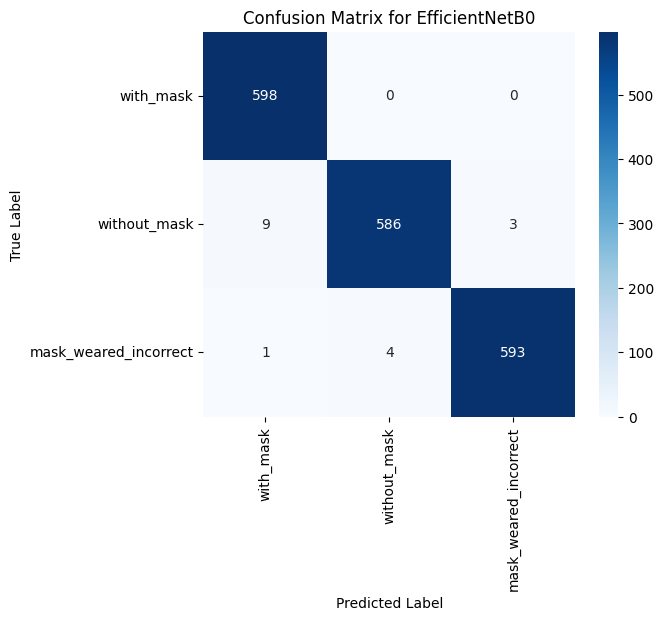

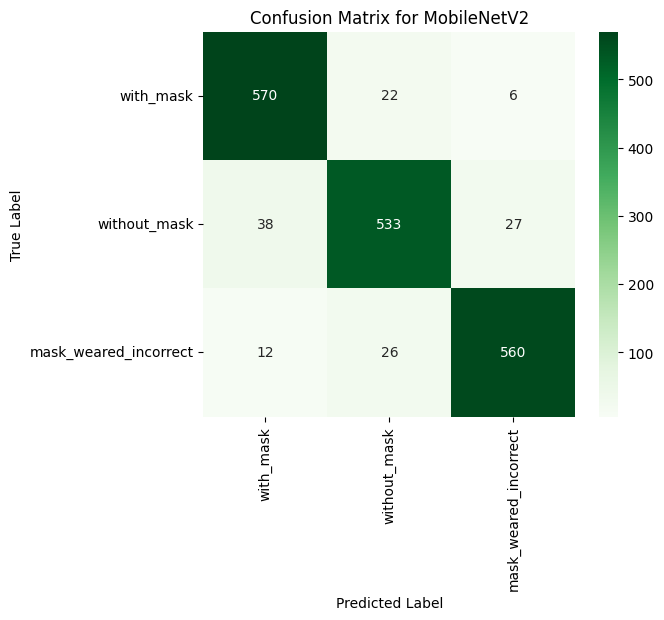

In [17]:
# Confusion Matrix for EfficientNetB0
cm_eff = confusion_matrix(y_true, y_pred_classes_eff)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_eff, annot=True, fmt='d', cmap='Blues', xticklabels=class_dirs, yticklabels=class_dirs)
plt.title('Confusion Matrix for EfficientNetB0')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Confusion Matrix for MobileNetV2
cm_mob = confusion_matrix(y_true, y_pred_classes_mob)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_mob, annot=True, fmt='d', cmap='Greens', xticklabels=class_dirs, yticklabels=class_dirs)
plt.title('Confusion Matrix for MobileNetV2')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Overall, both models show high performance, being able to accurately predict most of the test images. However, **EfficientNet-B0** significantly outperforms **MobileNetV2**, reducing the number of misclassifications from roughly 130 instances (MobileNetV2) to fewer than 20 (EfficientNet). This validates **EfficientNet** as the far **more reliable choice** for distinguishing between subtle classes like 'Incorrect Mask' and 'Without Mask'.

### 5.3 Inference Speed Test (FPS)
Runs 100 dummy images through both models and times them.

In [18]:
import time, json

# Inference Speed Test (FPS)
print("[INFO] Running inference speed test...")
num_test_iterations = 100
dummy_image = np.random.rand(224, 224, 3)
dummy_batch = np.expand_dims(dummy_image, axis=0)

# Test EfficientNet
start_time = time.time()
for _ in range(num_test_iterations):
    model_eff.predict(dummy_batch, verbose=0)
eff_time = time.time() - start_time
eff_fps = num_test_iterations / eff_time

# Test MobileNet
start_time = time.time()
for _ in range(num_test_iterations):
    model_mob.predict(dummy_batch, verbose=0)
mob_time = time.time() - start_time
mob_fps = num_test_iterations / mob_time

print(f"EfficientNet-B0 FPS: {eff_fps:.2f} (Total time for {num_test_iterations} iterations: {eff_time:.2f}s)")
print(f"MobileNetV2 FPS: {mob_fps:.2f} (Total time for {num_test_iterations} iterations: {mob_time:.2f}s)")

# Summary using training history
history_path = os.path.join(os.getcwd(), 'training_history.json')
eff_val_acc = None
mob_val_acc = None
if os.path.exists(history_path):
    try:
        with open(history_path, 'r') as f:
            loaded_hist = json.load(f)
        eff_hist = loaded_hist.get('EfficientNetB0', {})
        mob_hist = loaded_hist.get('MobileNetV2', {})
        eff_vals = eff_hist.get('val_accuracy', [])
        mob_vals = mob_hist.get('val_accuracy', [])
        eff_val_acc = eff_vals[-1] if eff_vals else None
        mob_val_acc = mob_vals[-1] if mob_vals else None
        print(f"[INFO] Loaded validation accuracies from {history_path}")
    except Exception as e:
        print(f"[WARNING] Failed to load training history: {e}")

# Fallback to in-memory history if JSON missing
if eff_val_acc is None and 'history_eff' in globals():
    eff_val_acc = history_eff.history['val_accuracy'][-1]
if mob_val_acc is None and 'history_mob' in globals():
    mob_val_acc = history_mob.history['val_accuracy'][-1]

# Print Summary
print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)
print(f"{'Metric':<30} {'EfficientNet-B0':<20} {'MobileNetV2':<20}")
print("-"*60)
print(f"{'Validation Accuracy':<30} {eff_val_acc if eff_val_acc is not None else 'N/A':<20} {mob_val_acc if mob_val_acc is not None else 'N/A':<20}")
print(f"{'Inference FPS':<30} {eff_fps:<20.2f} {mob_fps:<20.2f}")
print("="*60)

[INFO] Running inference speed test...
EfficientNet-B0 FPS: 6.94 (Total time for 100 iterations: 14.41s)
MobileNetV2 FPS: 9.01 (Total time for 100 iterations: 11.10s)
[INFO] Loaded validation accuracies from c:\Users\HP\10_JupyterLab_DataSc\notebooks\Visual Information Processing\VIP_Project_Group_10\Real-Time-Face-Mask-Detection\training_history.json

MODEL COMPARISON SUMMARY
Metric                         EfficientNet-B0      MobileNetV2         
------------------------------------------------------------
Validation Accuracy            0.9894091486930847   0.9102563858032227  
Inference FPS                  6.94                 9.01                


In terms of efficiency, **MobileNetV2** performs better than **EfficientNet-B0**, with mobileNetv2 having ~9 fps, while EfficientNet-B0 with ~6.9 fps. However, this gain in speed comes at a significant cost in reliability. While MobileNetV2 processes frames slightly faster, its validation accuracy drops by nearly 8% (**91.0%** for MobileNetV2 vs. **98.9%** for EfficientNet-B0).

In conclusion, **EfficientNet-B0** would be the superior choice to be implemented into our real-time mask detection system, as it shows significantly **higher reliability** with only a slight trade-off in speed (~2 fps). Its ability to correctly identify subtle non-compliance cases makes it the safer option for deployment, whereas MobileNetV2's frequent misclassifications makes it unsuitable for strict monitoring for mask wearing.

## 6.0 Application Simulation

Run in terminal:

`python real_time_mask_detector.py`


Available face detectors:
- dnn (default)
- yunet
- mtcnn (Very low FPS) (just for demonstration purposes)
- haar (Low accuracy) (just for demonstration purposes)

Available mask detector models:
- mask_detector_efficientnet.h5 (default)
- mask_detector_mobilenetv2.h5